# Taller 8 — Problema 5: Esfera conductora biseccionada
## Implementación numérica y visualización del potencial

**Universidad de Antioquia**  
**Curso:** Física Matemática I  

En este notebook se implementan los resultados analíticos del **Problema 5** del Taller 8. Una esfera conductora de radio $a$ se separa en dos hemisferios: el superior a potencial $V_0$ y el inferior a potencial cero. Se evalúa el potencial electrostático en el interior y en el exterior mediante la expansión en polinomios de Legendre y se construyen varias visualizaciones para explorar la solución.


## Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import eval_legendre
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f6f6f6",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "lines.linewidth": 2.2,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

COLORS = plt.cm.tab10.colors
print("Librerías importadas")


Librerías importadas


## Parámetros y funciones del potencial

Las expresiones analíticas obtenidas en el taller son:

$$\phi_{\text{int}}(r,\theta)=\frac{V_0}{2}+\frac{V_0}{2}\sum_{n=0}^{\infty}\left[P_{2n}(0)-P_{2n+2}(0)\right]\left(\frac{r}{a}\right)^{2n+1}P_{2n+1}(\cos\theta)$$

$$\phi_{\text{ext}}(r,\theta)=\frac{V_0}{2}\left(\frac{a}{r}\right)+\frac{V_0}{2}\sum_{n=0}^{\infty}\left[P_{2n}(0)-P_{2n+2}(0)\right]\left(\frac{a}{r}\right)^{2n+2}P_{2n+1}(\cos\theta)$$

A continuación se implementan estas series con un número finito de términos.


In [2]:
a = 1.0
V0 = 1.0
N_TERMS = 25


def odd_coeffs(n_terms, v0=V0):
    n = np.arange(n_terms)
    p_even = eval_legendre(2 * n, 0.0)
    p_even_next = eval_legendre(2 * n + 2, 0.0)
    coeffs = 0.5 * v0 * (p_even - p_even_next)
    l_vals = 2 * n + 1
    return l_vals, coeffs


def phi_int(r, theta, n_terms=N_TERMS, a=a, v0=V0):
    r, theta = np.broadcast_arrays(np.asarray(r, dtype=float), np.asarray(theta, dtype=float))
    x = np.cos(theta)
    phi = 0.5 * v0 * np.ones_like(r)
    l_vals, coeffs = odd_coeffs(n_terms, v0=v0)
    for l, c in zip(l_vals, coeffs):
        phi += c * (r / a) ** l * eval_legendre(l, x)
    return phi


def phi_ext(r, theta, n_terms=N_TERMS, a=a, v0=V0):
    r, theta = np.broadcast_arrays(np.asarray(r, dtype=float), np.asarray(theta, dtype=float))
    x = np.cos(theta)
    phi = 0.5 * v0 * (a / r)
    l_vals, coeffs = odd_coeffs(n_terms, v0=v0)
    for l, c in zip(l_vals, coeffs):
        phi += c * (a / r) ** (l + 1) * eval_legendre(l, x)
    return phi


def phi_total(r, theta, n_terms=N_TERMS, a=a, v0=V0):
    r, theta = np.broadcast_arrays(np.asarray(r, dtype=float), np.asarray(theta, dtype=float))
    phi = np.empty_like(r, dtype=float)
    inside = r <= a
    phi[inside] = phi_int(r[inside], theta[inside], n_terms=n_terms, a=a, v0=v0)
    phi[~inside] = phi_ext(r[~inside], theta[~inside], n_terms=n_terms, a=a, v0=v0)
    return phi


l_vals, coeffs = odd_coeffs(6)
for l, c in zip(l_vals, coeffs):
    print(f"l={l:2d}  C_l = {c:+.6f}")


l= 1  C_l = +0.750000
l= 3  C_l = -0.437500
l= 5  C_l = +0.343750
l= 7  C_l = -0.292969
l= 9  C_l = +0.259766
l=11  C_l = -0.235840


## Potencial sobre la superficie ($r=a$)

Comparación entre la condición de frontera ideal y la serie truncada. Se observa el fenómeno de Gibbs cerca del ecuador.


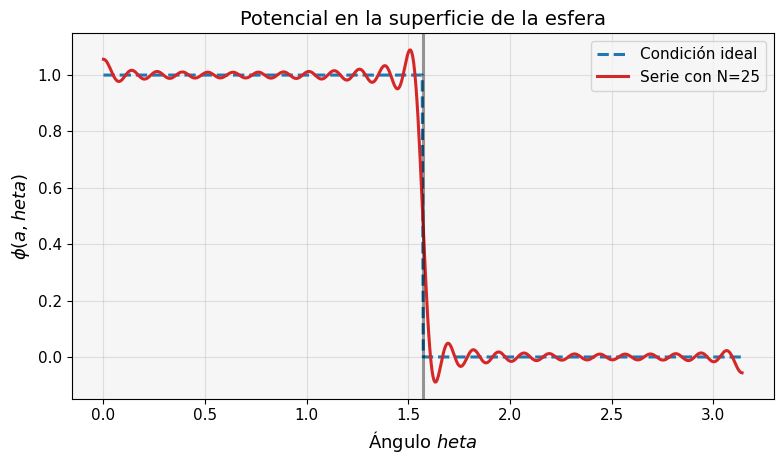

In [3]:
theta = np.linspace(0, np.pi, 600)
V_boundary = np.where(theta <= np.pi / 2, V0, 0.0)
V_series = phi_int(a, theta, n_terms=N_TERMS)

plt.figure(figsize=(8, 4.8))
plt.plot(theta, V_boundary, color=COLORS[0], linestyle="--", label="Condición ideal")
plt.plot(theta, V_series, color=COLORS[3], label=f"Serie con N={N_TERMS}")
plt.axvline(np.pi / 2, color="black", alpha=0.4)
plt.xlabel(r"Ángulo $	heta$")
plt.ylabel(r"$\phi(a,	heta)$")
plt.title("Potencial en la superficie de la esfera")
plt.legend()
plt.tight_layout()


## Mapa 2D del potencial (corte meridional)

El potencial se visualiza en el plano $(x,z)$ con simetría axial. Se resaltan líneas equipotenciales y la frontera $r=a$.


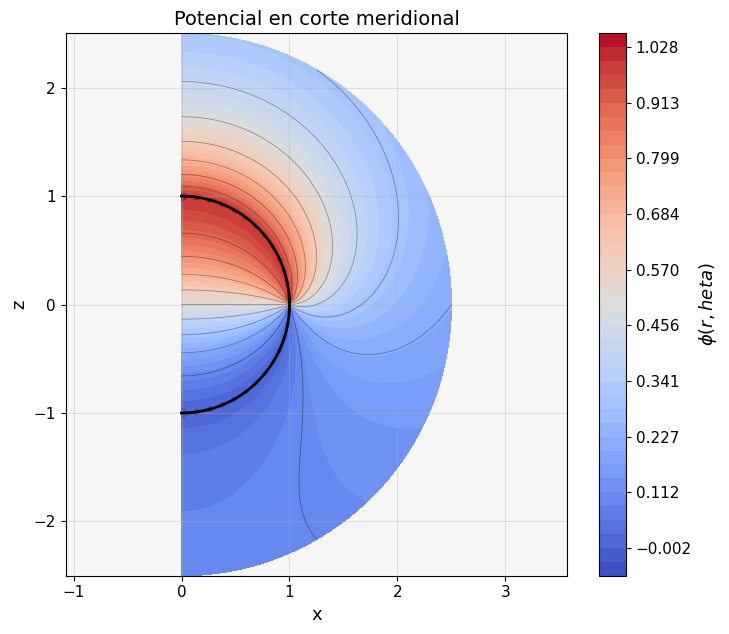

In [4]:
r = np.linspace(0, 2.5 * a, 320)
theta = np.linspace(0, np.pi, 360)
R, Theta = np.meshgrid(r, theta)
Phi = phi_total(R, Theta, n_terms=N_TERMS)

X = R * np.sin(Theta)
Z = R * np.cos(Theta)

plt.figure(figsize=(7.5, 6.5))
levels = np.linspace(np.min(Phi), np.max(Phi), 40)
contour = plt.contourf(X, Z, Phi, levels=levels, cmap="coolwarm")
plt.contour(X, Z, Phi, levels=12, colors="k", alpha=0.35, linewidths=0.6)
plt.colorbar(contour, label=r"$\phi(r,	heta)$")

circle_theta = np.linspace(0, np.pi, 200)
plt.plot(a * np.sin(circle_theta), a * np.cos(circle_theta), color="black", linewidth=2)

plt.xlabel("x")
plt.ylabel("z")
plt.title("Potencial en corte meridional")
plt.axis("equal")
plt.tight_layout()


## Perfiles radiales para distintos ángulos

Se comparan las curvas $\phi(r)$ para varios valores de $	heta$.

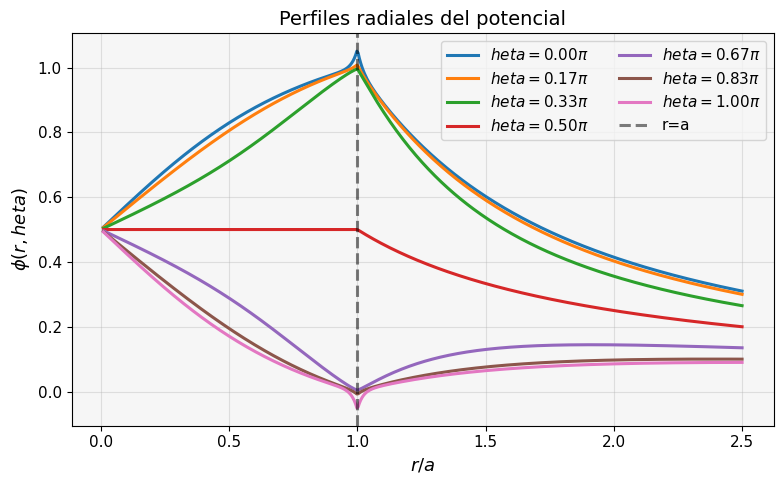

In [5]:
r_line = np.linspace(0.01 * a, 2.5 * a, 500)
angles = [0, np.pi / 6, np.pi / 3, np.pi / 2, 2 * np.pi / 3, 5 * np.pi / 6, np.pi]

plt.figure(figsize=(8, 5))
for idx, ang in enumerate(angles):
    phi_vals = np.where(r_line <= a,
                        phi_int(r_line, ang, n_terms=N_TERMS),
                        phi_ext(r_line, ang, n_terms=N_TERMS))
    plt.plot(r_line / a, phi_vals, color=COLORS[idx % len(COLORS)],
             label=fr"$	heta={ang/np.pi:.2f}\pi$")

plt.axvline(1.0, color="black", linestyle="--", alpha=0.5, label="r=a")
plt.xlabel(r"$r/a$")
plt.ylabel(r"$\phi(r,	heta)$")
plt.title("Perfiles radiales del potencial")
plt.legend(ncol=2)
plt.tight_layout()


## Convergencia de la serie en un punto

Se analiza la convergencia de la serie truncada en un punto representativo dentro de la esfera.

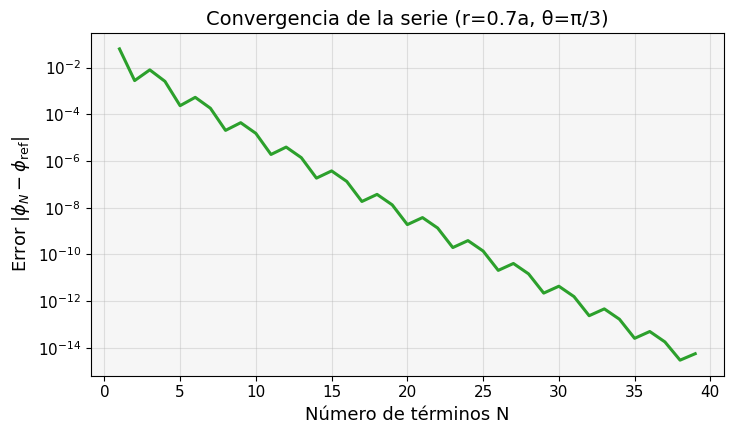

In [6]:
r0 = 0.7 * a
theta0 = np.pi / 3
n_values = np.arange(1, 40)
phi_values = np.array([phi_int(r0, theta0, n_terms=n) for n in n_values])
phi_ref = phi_int(r0, theta0, n_terms=80)

plt.figure(figsize=(7.5, 4.5))
plt.plot(n_values, np.abs(phi_values - phi_ref), color=COLORS[2])
plt.yscale("log")
plt.xlabel("Número de términos N")
plt.ylabel(r"Error $|\phi_N-\phi_{\mathrm{ref}}|$")
plt.title("Convergencia de la serie (r=0.7a, θ=π/3)")
plt.tight_layout()


## Potencial sobre la superficie en 3D

Visualización de la distribución de potencial sobre la esfera usando la serie truncada.


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

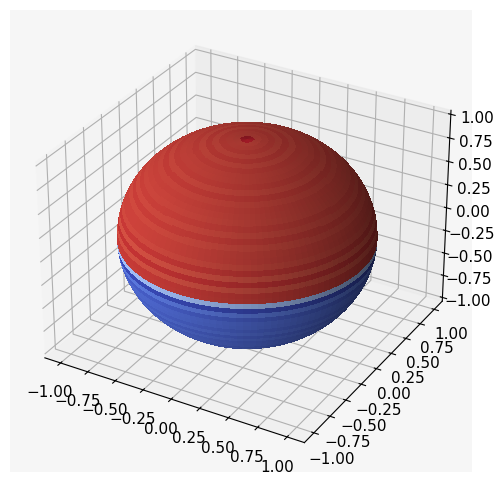

In [7]:
theta = np.linspace(0, np.pi, 120)
phi = np.linspace(0, 2 * np.pi, 240)
Theta, Phi = np.meshgrid(theta, phi)

X = a * np.sin(Theta) * np.cos(Phi)
Y = a * np.sin(Theta) * np.sin(Phi)
Z = a * np.cos(Theta)

V_surface = phi_int(a, Theta, n_terms=N_TERMS)

fig = plt.figure(figsize=(7.5, 6.0))
ax = fig.add_subplot(111, projection="3d")

norm = plt.Normalize(V_surface.min(), V_surface.max())
colors = cm.coolwarm(norm(V_surface))
ax.plot_surface(X, Y, Z, facecolors=colors, rstride=2, cstride=2, linewidth=0, antialiased=False)

mappable = cm.ScalarMappable(cmap="coolwarm", norm=norm)
mappable.set_array(V_surface)
fig.colorbar(mappable, shrink=0.65, pad=0.08, label=r"$\phi(a,	heta)$")

ax.set_title("Potencial sobre la superficie (3D)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(elev=25, azim=35)
plt.tight_layout()


# Taller 8 — Problema 6: Anillo cargado uniforme
## Potencial y campo eléctrico mediante expansión de Legendre

Para un anillo de radio $R$ con carga total $q$ (densidad lineal uniforme), el potencial electrostático en regiones libres de carga se puede expresar como una serie de polinomios de Legendre. Las expresiones analíticas son:

$$\phi_{\text{ext}}(r,\theta)=\frac{q}{4\pi\epsilon_0}\sum_{k=0}^{\infty}P_{2k}(0)\frac{R^{2k}}{r^{2k+1}}P_{2k}(\cos\theta), \quad r>R$$

$$\phi_{\text{int}}(r,\theta)=\frac{q}{4\pi\epsilon_0 R}\sum_{k=0}^{\infty}P_{2k}(0)\left(\frac{r}{R}\right)^{2k}P_{2k}(\cos\theta), \quad r<R$$

En lo que sigue se implementa la serie truncada, junto con visualizaciones del potencial y del campo eléctrico.


## Parámetros y funciones (Problema 6)


In [ ]:
R_RING = 1.0
Q_RING = 1.0
EPS0 = 1.0
N_TERMS_RING = 20
SINGULARITY_EPS = 1e-10


def even_legendre_coeffs(n_terms):
    k = np.arange(n_terms)
    l_vals = 2 * k
    coeffs = np.array([eval_legendre(l, 0.0) for l in l_vals])
    return l_vals, coeffs


def phi_ring_int(r, theta, n_terms=N_TERMS_RING, R=R_RING, q=Q_RING, eps0=EPS0):
    r, theta = np.broadcast_arrays(np.asarray(r, dtype=float), np.asarray(theta, dtype=float))
    x = np.cos(theta)
    l_vals, coeffs = even_legendre_coeffs(n_terms)
    series = np.zeros_like(r, dtype=float)
    for l, c in zip(l_vals, coeffs):
        series += c * (r / R) ** l * eval_legendre(l, x)
    return (q / (4 * np.pi * eps0 * R)) * series


def phi_ring_ext(r, theta, n_terms=N_TERMS_RING, R=R_RING, q=Q_RING, eps0=EPS0):
    r, theta = np.broadcast_arrays(np.asarray(r, dtype=float), np.asarray(theta, dtype=float))
    x = np.cos(theta)
    l_vals, coeffs = even_legendre_coeffs(n_terms)
    series = np.zeros_like(r, dtype=float)
    for l, c in zip(l_vals, coeffs):
        series += c * (R ** l) / (r ** (l + 1)) * eval_legendre(l, x)
    return (q / (4 * np.pi * eps0)) * series


def phi_ring(r, theta, n_terms=N_TERMS_RING, R=R_RING, q=Q_RING, eps0=EPS0):
    r, theta = np.broadcast_arrays(np.asarray(r, dtype=float), np.asarray(theta, dtype=float))
    phi = np.empty_like(r, dtype=float)
    inside = r <= R
    phi[inside] = phi_ring_int(r[inside], theta[inside], n_terms=n_terms, R=R, q=q, eps0=eps0)
    phi[~inside] = phi_ring_ext(r[~inside], theta[~inside], n_terms=n_terms, R=R, q=q, eps0=eps0)
    return phi


def legendre_derivative(l, x, Pl=None):
    if l == 0:
        return np.zeros_like(x)
    if Pl is None:
        Pl = eval_legendre(l, x)
    Plm1 = eval_legendre(l - 1, x)
    denom = x ** 2 - 1.0
    dPl = l * (x * Pl - Plm1) / denom
    return np.where(np.abs(denom) < SINGULARITY_EPS, 0.0, dPl)


def ring_field_spherical(r, theta, n_terms=N_TERMS_RING, R=R_RING, q=Q_RING, eps0=EPS0):
    r, theta = np.broadcast_arrays(np.asarray(r, dtype=float), np.asarray(theta, dtype=float))
    r_safe = np.where(r < 1e-9, 1e-9, r)
    x = np.cos(theta)
    sin_t = np.sin(theta)
    Er = np.zeros_like(r_safe, dtype=float)
    Et = np.zeros_like(r_safe, dtype=float)
    l_vals, coeffs = even_legendre_coeffs(n_terms)
    inside = r <= R
    for l, c in zip(l_vals, coeffs):
        Pl = eval_legendre(l, x)
        dPl = legendre_derivative(l, x, Pl)
        ext_r = (l + 1) * c * (R ** l) / (r_safe ** (l + 2)) * Pl
        ext_t = c * (R ** l) / (r_safe ** (l + 2)) * dPl * sin_t
        if l == 0:
            int_r = np.zeros_like(r_safe)
            int_t = np.zeros_like(r_safe)
        else:
            int_r = -l * c / (R ** (l + 1)) * (r_safe ** (l - 1)) * Pl
            int_t = c / (R ** (l + 1)) * (r_safe ** (l - 1)) * dPl * sin_t
        Er += np.where(inside, int_r, ext_r)
        Et += np.where(inside, int_t, ext_t)
    factor = q / (4 * np.pi * eps0)
    return factor * Er, factor * Et


def ring_field_cylindrical(rho, z, n_terms=N_TERMS_RING, R=R_RING, q=Q_RING, eps0=EPS0):
    r = np.sqrt(rho ** 2 + z ** 2)
    r_safe = np.where(r < 1e-9, 1e-9, r)
    theta = np.arccos(np.clip(z / r_safe, -1.0, 1.0))
    Er, Et = ring_field_spherical(r_safe, theta, n_terms=n_terms, R=R, q=q, eps0=eps0)
    sin_t = np.sin(theta)
    cos_t = np.cos(theta)
    E_rho = Er * sin_t + Et * cos_t
    E_z = Er * cos_t - Et * sin_t
    return E_rho, E_z


## Potencial sobre el eje de simetría


In [ ]:
z = np.linspace(-3 * R_RING, 3 * R_RING, 600)
r_axis = np.abs(z)
theta_axis = np.where(z >= 0, 0.0, np.pi)

phi_series = phi_ring(r_axis, theta_axis, n_terms=N_TERMS_RING)
phi_exact = Q_RING / (4 * np.pi * EPS0) / np.sqrt(R_RING ** 2 + z ** 2)

plt.figure(figsize=(8, 4.8))
plt.plot(z / R_RING, phi_exact, color=COLORS[0], label="Exacto en el eje")
plt.plot(z / R_RING, phi_series, color=COLORS[3], linestyle="--", label=f"Serie N={N_TERMS_RING}")
plt.axvline(1.0, color="black", linestyle=":", alpha=0.6)
plt.axvline(-1.0, color="black", linestyle=":", alpha=0.6)
plt.xlabel(r"$z/R$")
plt.ylabel(r"$\phi(z)$")
plt.title("Potencial sobre el eje de simetría")
plt.legend()
plt.tight_layout()


## Mapa 2D del potencial (plano meridional)


In [ ]:
x = np.linspace(-2.5 * R_RING, 2.5 * R_RING, 320)
z = np.linspace(-2.5 * R_RING, 2.5 * R_RING, 320)
X, Z = np.meshgrid(x, z)
r = np.sqrt(X ** 2 + Z ** 2)
r_safe = np.where(r < 1e-9, 1e-9, r)
theta = np.arccos(np.clip(Z / r_safe, -1.0, 1.0))
Phi = phi_ring(r_safe, theta, n_terms=N_TERMS_RING)

plt.figure(figsize=(7.5, 6.5))
levels = np.linspace(np.min(Phi), np.max(Phi), 40)
contour = plt.contourf(X / R_RING, Z / R_RING, Phi, levels=levels, cmap="coolwarm")
plt.contour(X / R_RING, Z / R_RING, Phi, levels=12, colors="k", alpha=0.35, linewidths=0.6)
plt.colorbar(contour, label=r"$\phi(r,\theta)$")
plt.scatter([1, -1], [0, 0], color="black", s=40, zorder=5, label="Anillo")
plt.xlabel(r"$x/R$")
plt.ylabel(r"$z/R$")
plt.title("Potencial en el plano meridional")
plt.axis("equal")
plt.tight_layout()


## Campo eléctrico en el plano meridional (campo vectorial)


In [ ]:
x = np.linspace(-2.0 * R_RING, 2.0 * R_RING, 200)
z = np.linspace(-2.0 * R_RING, 2.0 * R_RING, 200)
X, Z = np.meshgrid(x, z)
rho = np.abs(X)

E_rho, E_z = ring_field_cylindrical(rho, Z, n_terms=N_TERMS_RING)
E_x = np.where(X >= 0, E_rho, -E_rho)
E_mag = np.sqrt(E_x ** 2 + E_z ** 2)

mask = (rho - R_RING) ** 2 + Z ** 2 < (0.08 * R_RING) ** 2
E_x = np.where(mask, np.nan, E_x)
E_z = np.where(mask, np.nan, E_z)
E_mag = np.where(mask, np.nan, E_mag)

plt.figure(figsize=(7.5, 6.5))
plt.streamplot(x / R_RING, z / R_RING, E_x, E_z, color=E_mag, cmap="viridis", density=1.4, linewidth=1)
plt.colorbar(label=r"$|\mathbf{E}|$")
plt.scatter([1, -1], [0, 0], color="black", s=35, zorder=5)
plt.xlabel(r"$x/R$")
plt.ylabel(r"$z/R$")
plt.title("Campo eléctrico en el plano meridional")
plt.axis("equal")
plt.tight_layout()
